# P01: Train a VAE Encoder

Train a compact convolutional Variational Autoencoder (VAE) on synthetic 64x64 RGB images. The encoder learns a 32-dimensional latent space that P02 reuses as its observation encoder. The goal here is not photorealistic generation; it is to learn a stable latent space that downstream notebooks can consume.

**Output**: this notebook trains from scratch (no prior checkpoint needed) and saves the trained weights to `vae_encoder.pt`, which P02 and P03 load as their observation encoder.

**Outline:**
1. Setup: synthetic data and DataLoader
2. Model: encoder, decoder, reparameterization
3. ELBO loss: reconstruction plus KL
4. Train: 30 epochs and loss curves
5. Inspect: reconstructions, traversals, random samples

In [1]:
# Install dependencies for a fresh environment.
!pip install torch torchvision matplotlib numpy


## 1. Setup

Generate synthetic colored shapes so the notebook runs offline with no external downloads.

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
try:
    from IPython import get_ipython
    get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    pass
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

try:
    import torch_xla.core.xla_model as xm
    _XLA_AVAILABLE = True
except Exception:
    xm = None
    _XLA_AVAILABLE = False


def _resolve_device():
    if _XLA_AVAILABLE:
        return xm.xla_device()
    if torch.cuda.is_available():
        return torch.device('cuda')
    return torch.device('cpu')


DEVICE = _resolve_device()
USE_TPU = DEVICE.type == 'xla'
USE_CUDA = DEVICE.type == 'cuda'
LOAD_DEVICE = torch.device('cpu') if USE_TPU else DEVICE


def optimizer_step(optimizer, scaler=None):
    if USE_TPU:
        xm.optimizer_step(optimizer)
    elif scaler is not None:
        scaler.step(optimizer)
        scaler.update()
    else:
        optimizer.step()

# Use faster kernels when CUDA is available.
if USE_CUDA:
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

print(f'Using device   : {DEVICE}')
if USE_TPU:
    print('TPU backend    : torch_xla')
elif USE_CUDA:
    print(f'GPU            : {torch.cuda.get_device_name(0)}')
    print(f'CUDA capability: {torch.cuda.get_device_capability(0)}')
print(f'PyTorch version: {torch.__version__}')

Using device   : cuda
GPU            : NVIDIA L4
CUDA capability: (8, 9)
PyTorch version: 2.11.0+cu128


With the runtime ready, generate a synthetic-shape dataset that the VAE can learn from without external downloads.

Dataset size : 1000
Image shape  : torch.Size([3, 64, 64])  (C, H, W)
Batches/epoch: 16


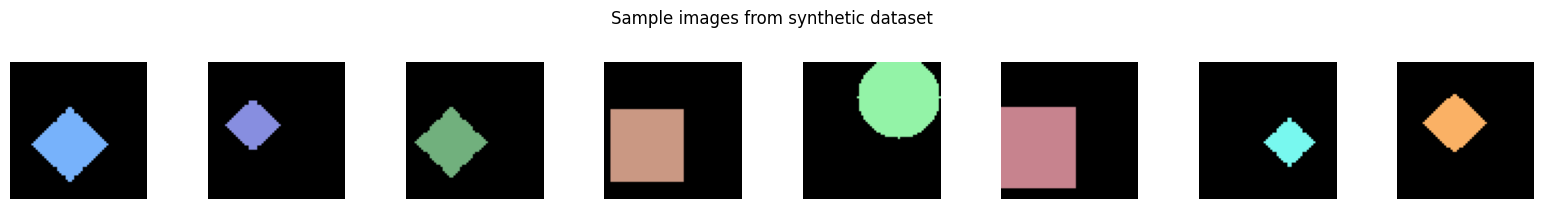

In [3]:
def make_shape_image(img_size=64):
    """Generate a single 64x64 RGB image containing a random colored shape."""
    rng = np.random.default_rng()
    img = np.zeros((img_size, img_size, 3), dtype=np.float32)

    shape_type = rng.integers(0, 3)
    color = rng.uniform(0.3, 1.0, size=3).astype(np.float32)

    cx = rng.integers(16, img_size - 16)
    cy = rng.integers(16, img_size - 16)
    r  = rng.integers(8, 20)

    if shape_type == 0:
        x0, x1 = max(0, cx - r), min(img_size, cx + r)
        y0, y1 = max(0, cy - r), min(img_size, cy + r)
        img[y0:y1, x0:x1] = color
    elif shape_type == 1:
        ys, xs = np.mgrid[0:img_size, 0:img_size]
        mask = (xs - cx) ** 2 + (ys - cy) ** 2 <= r ** 2
        img[mask] = color
    else:
        for row in range(img_size):
            half_w = int(r * (1 - abs(row - cy) / max(r, 1)))
            if half_w > 0:
                c0 = max(0, cx - half_w)
                c1 = min(img_size, cx + half_w)
                img[row, c0:c1] = color

    return torch.from_numpy(img.transpose(2, 0, 1))


class ShapeDataset(Dataset):
    def __init__(self, n_samples=1000, img_size=64, seed=42):
        torch.manual_seed(seed)
        np.random.seed(seed)
        # Store the dataset as one tensor for cheap indexing.
        self.images = torch.stack([make_shape_image(img_size) for _ in range(n_samples)])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx]


dataset = ShapeDataset(n_samples=1000)

dataloader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2 if USE_CUDA else 0,
    pin_memory=USE_CUDA,
)

print(f'Dataset size : {len(dataset)}')
print(f'Image shape  : {dataset[0].shape}  (C, H, W)')
print(f'Batches/epoch: {len(dataloader)}')

# Quick sanity check.
fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for i, ax in enumerate(axes):
    ax.imshow(dataset[i].permute(1, 2, 0).numpy())
    ax.axis('off')
fig.suptitle('Sample images from synthetic dataset', y=1.02)
plt.tight_layout()
plt.show()

## 2. Model

Encoder: four strided convolutional layers compress a 3x64x64 image to a latent vector, then two linear heads produce `mu` and `log_var`.

Decoder: a linear layer expands the latent vector back to a feature map, then four transposed convolutional layers reconstruct 3x64x64.

Reparameterization samples `z = mu + sigma * epsilon` with `epsilon ~ N(0, I)` so the sampling step stays differentiable.

In [4]:
LATENT_DIM = 32
IMG_SIZE   = 64
IMG_CH     = 3


class Encoder(nn.Module):
    """Encode 3x64x64 images into latent mean and log-variance."""

    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(IMG_CH, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
        )
        self.flat_dim = 256 * 4 * 4
        self.fc_mu = nn.Linear(self.flat_dim, latent_dim)
        self.fc_log_var = nn.Linear(self.flat_dim, latent_dim)

    def forward(self, x):
        h = self.conv(x).flatten(start_dim=1)
        return self.fc_mu(h), self.fc_log_var(h)


class Decoder(nn.Module):
    """Decode latent vectors back to 3x64x64 images."""

    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.flat_dim = 256 * 4 * 4
        self.fc = nn.Linear(latent_dim, self.flat_dim)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, IMG_CH, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, z):
        h = self.fc(z).view(-1, 256, 4, 4)
        return self.deconv(h)


class VAE(nn.Module):
    """Variational Autoencoder combining encoder and decoder."""

    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def reparameterize(self, mu, log_var):
        """Sample z = mu + sigma * epsilon."""
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + std * eps

    def forward(self, x):
        mu, log_var = self.encoder(x)
        z = self.reparameterize(mu, log_var)
        recon = self.decoder(z)
        return recon, mu, log_var

    def encode(self, x):
        """Return the latent mean without sampling."""
        mu, _ = self.encoder(x)
        return mu

    def decode(self, z):
        return self.decoder(z)


model = VAE(latent_dim=LATENT_DIM).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')

# Verify shapes with a dummy forward pass.
dummy = torch.zeros(4, IMG_CH, IMG_SIZE, IMG_SIZE).to(DEVICE)
recon_dummy, mu_dummy, lv_dummy = model(dummy)
print(f'Input  shape : {dummy.shape}')
print(f'mu shape     : {mu_dummy.shape}')
print(f'log_var shape: {lv_dummy.shape}')
print(f'Recon  shape : {recon_dummy.shape}')

Total parameters: 1,777,411
Input  shape : torch.Size([4, 3, 64, 64])
mu shape     : torch.Size([4, 32])
log_var shape: torch.Size([4, 32])
Recon  shape : torch.Size([4, 3, 64, 64])


## 3. ELBO Loss

ELBO balances reconstruction and regularisation:

$$\mathcal{L} = \underbrace{\mathbb{E}[\log p(x|z)]}_{\text{reconstruction}} - \underbrace{D_{KL}(q(z|x) \| p(z))}_{\text{regularisation}}$$

We use MSE for reconstruction and the closed-form KL for diagonal Gaussians:

$$D_{KL} = -\frac{1}{2} \sum_j \left(1 + \log\sigma_j^2 - \mu_j^2 - \sigma_j^2\right)$$

Tracking both terms helps catch posterior collapse early.

In [5]:
def elbo_loss(recon_x, x, mu, log_var, kl_weight=1.0):
    """
    ELBO loss = reconstruction loss + KL divergence.

    Returns:
        total_loss : scalar tensor (for backward)
        recon_loss : scalar tensor (for logging)
        kl_loss    : scalar tensor (for logging)
    """
    # Mean squared reconstruction error.
    recon_loss = F.mse_loss(recon_x, x, reduction='mean')

    # Closed-form KL for a diagonal Gaussian posterior.
    kl_loss = -0.5 * torch.mean(
        torch.sum(1 + log_var - mu.pow(2) - log_var.exp(), dim=1)
    )
    # Scale KL so it is comparable to the reconstruction term.
    kl_loss = kl_loss / (IMG_CH * IMG_SIZE * IMG_SIZE)

    total_loss = recon_loss + kl_weight * kl_loss
    return total_loss, recon_loss, kl_loss


# Quick sanity check.
with torch.no_grad():
    sample_batch = dataset[:4].to(DEVICE)
    r, mu_, lv_ = model(sample_batch)
    total, recon, kl = elbo_loss(r, sample_batch, mu_, lv_)

print(f'Initial total loss  : {total.item():.4f}')
print(f'Initial recon loss  : {recon.item():.4f}')
print(f'Initial KL loss     : {kl.item():.6f}')

Initial total loss  : 0.2119
Initial recon loss  : 0.2119
Initial KL loss     : 0.000000


## 4. Training Loop

Train for 30 epochs with Adam (`lr = 1e-3`) and batch size 64. The plot uses two y-axes so reconstruction and KL stay readable on the same figure.

In [6]:
EPOCHS     = 30
LR         = 1e-3
# KL is averaged over pixels in elbo_loss, so a weight above 1 keeps the
# latent space close to N(0, I) (better prior samples and traversals)
# without measurably hurting reconstruction on this simple data.
KL_WEIGHT  = 3.0

optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# Mixed precision speeds up CUDA training and falls back cleanly on CPU.
scaler = torch.amp.GradScaler('cuda', enabled=USE_CUDA)

history_recon = []
history_kl    = []

model.train()
for epoch in range(1, EPOCHS + 1):
    epoch_recon = 0.0
    epoch_kl    = 0.0
    n_batches   = 0

    for batch in dataloader:
        batch = batch.to(DEVICE, non_blocking=USE_CUDA)
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda', enabled=USE_CUDA):
            recon_batch, mu, log_var = model(batch)
            loss, recon_loss, kl_loss = elbo_loss(
                recon_batch, batch, mu, log_var, kl_weight=KL_WEIGHT
            )

        scaler.scale(loss).backward()
        optimizer_step(optimizer, scaler)

        epoch_recon += recon_loss.item()
        epoch_kl    += kl_loss.item()
        n_batches   += 1

    avg_recon = epoch_recon / n_batches
    avg_kl    = epoch_kl    / n_batches
    history_recon.append(avg_recon)
    history_kl.append(avg_kl)

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{EPOCHS} | '
              f'Recon: {avg_recon:.5f} | KL: {avg_kl:.6f}')

print('\nTraining complete.')

Epoch   1/30 | Recon: 0.12674 | KL: 0.001969
Epoch   5/30 | Recon: 0.04968 | KL: 0.000565
Epoch  10/30 | Recon: 0.02088 | KL: 0.001458
Epoch  15/30 | Recon: 0.01750 | KL: 0.001440
Epoch  20/30 | Recon: 0.01359 | KL: 0.001444
Epoch  25/30 | Recon: 0.01283 | KL: 0.001323
Epoch  30/30 | Recon: 0.01247 | KL: 0.001207

Training complete.


Now that the training budget is fixed, wire the dataset into an epoch iterator and a DataLoader for minibatch updates.

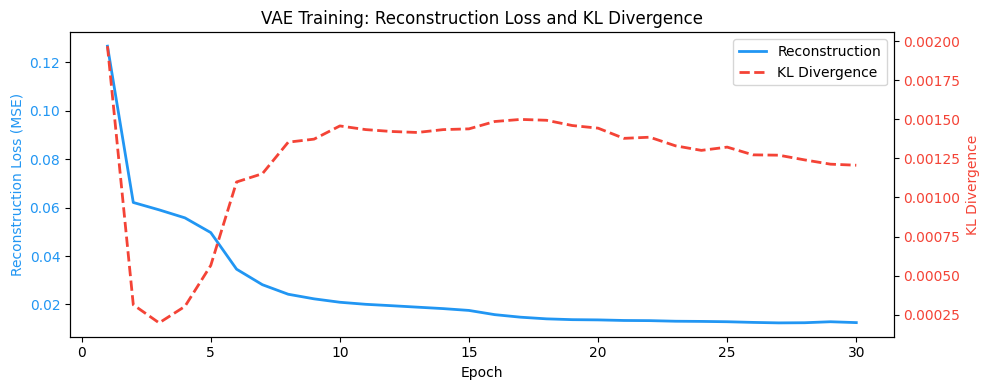

Final reconstruction loss : 0.01247
Final KL divergence       : 0.001207


In [7]:
epochs_range = range(1, EPOCHS + 1)

fig, ax1 = plt.subplots(figsize=(10, 4))

color_recon = '#2196F3'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Reconstruction Loss (MSE)', color=color_recon)
ax1.plot(epochs_range, history_recon, color=color_recon, linewidth=2, label='Reconstruction')
ax1.tick_params(axis='y', labelcolor=color_recon)

ax2 = ax1.twinx()
color_kl = '#F44336'
ax2.set_ylabel('KL Divergence', color=color_kl)
ax2.plot(epochs_range, history_kl, color=color_kl, linewidth=2, linestyle='--', label='KL Divergence')
ax2.tick_params(axis='y', labelcolor=color_kl)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title('VAE Training: Reconstruction Loss and KL Divergence')
fig.tight_layout()
plt.show()

print(f'Final reconstruction loss : {history_recon[-1]:.5f}')
print(f'Final KL divergence       : {history_kl[-1]:.6f}')

After the loop is in place, switch to a held-out batch and compare reconstructions to check whether the encoder-decoder pair is learning structure.

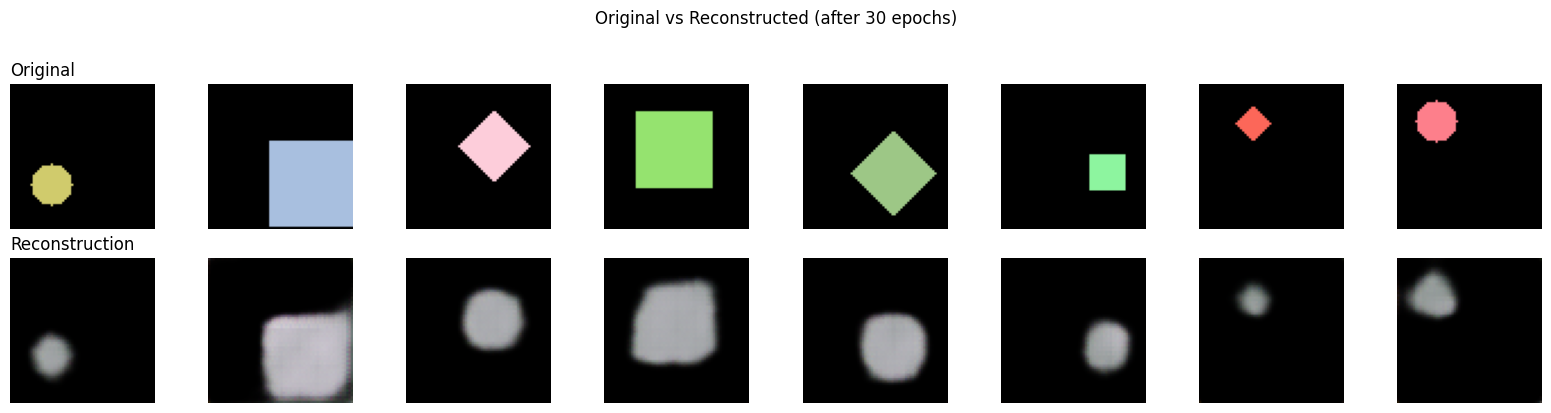

In [8]:
# Visual comparison: original vs reconstruction for a held-out batch
model.eval()
with torch.no_grad():
    sample = dataset[200:208].to(DEVICE)
    recon, _, _ = model(sample)

n_show = 8
fig, axes = plt.subplots(2, n_show, figsize=(16, 4))
for i in range(n_show):
    axes[0, i].imshow(sample[i].cpu().permute(1, 2, 0).numpy())
    axes[0, i].axis('off')
    axes[1, i].imshow(recon[i].cpu().permute(1, 2, 0).numpy())
    axes[1, i].axis('off')

axes[0, 0].set_title('Original', loc='left', fontsize=12)
axes[1, 0].set_title('Reconstruction', loc='left', fontsize=12)
plt.suptitle('Original vs Reconstructed (after 30 epochs)', y=1.02)
plt.tight_layout()
plt.show()

## 5. Latent Space Visualization

Vary one latent dimension at a time while keeping the others at zero. The row-wise changes show which directions the decoder uses most.

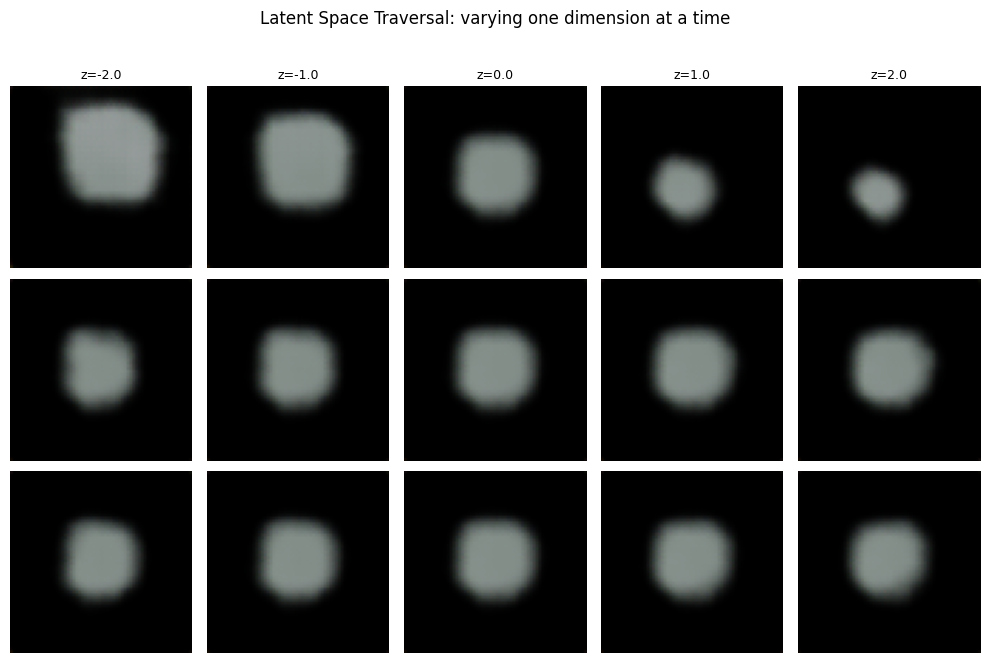

In [9]:
model.eval()

# Dimensions to sweep and sweep values
dims_to_vary = [0, 1, 2]
sweep_values = np.linspace(-2, 2, 5)

n_rows = len(dims_to_vary)
n_cols = len(sweep_values)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2, n_rows * 2 + 0.5))

with torch.no_grad():
    for row_idx, dim in enumerate(dims_to_vary):
        for col_idx, val in enumerate(sweep_values):
            z = torch.zeros(1, LATENT_DIM, device=DEVICE)
            z[0, dim] = float(val)
            decoded = model.decode(z)  # shape: (1, 3, 64, 64)
            img = decoded[0].cpu().permute(1, 2, 0).numpy()  # (64, 64, 3)

            ax = axes[row_idx, col_idx]
            ax.imshow(img)
            ax.axis('off')
            if col_idx == 0:
                ax.set_ylabel(f'dim {dim}', fontsize=10, rotation=0, labelpad=30, va='center')

# Column headers
for col_idx, val in enumerate(sweep_values):
    axes[0, col_idx].set_title(f'z={val:.1f}', fontsize=9)

plt.suptitle('Latent Space Traversal: varying one dimension at a time', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

Once reconstructions look stable, sample from the latent prior to see what kinds of shapes the model has compressed into latent space.

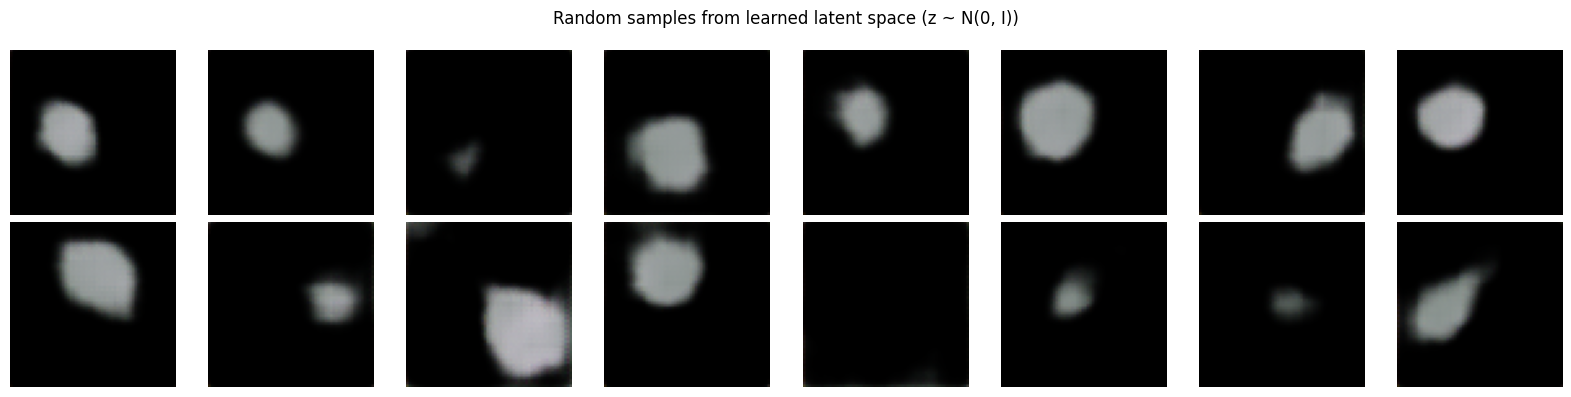

In [10]:
# Sample from the learned prior.
model.eval()
torch.manual_seed(42)

n_samples = 16
with torch.no_grad():
    z_random = torch.randn(n_samples, LATENT_DIM, device=DEVICE)
    samples  = model.decode(z_random)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(samples[i].cpu().permute(1, 2, 0).numpy())
    ax.axis('off')

plt.suptitle('Random samples from learned latent space (z ~ N(0, I))', fontsize=12)
plt.tight_layout()
plt.show()

## Save Checkpoint

Save the checkpoint as `vae_encoder.pt` so P02 and P03 can reuse the encoder weights. A good run should end with low reconstruction loss, visually coherent reconstructions, and latent traversals that change the decoded shape in a predictable way.

In [11]:
import os

checkpoint_path = 'vae_encoder.pt'
torch.save({
    'model_state_dict': model.state_dict(),
    'encoder':          model.encoder.state_dict(),
    'decoder':          model.decoder.state_dict(),
    'latent_dim':       LATENT_DIM,
    'img_size':         IMG_SIZE,
    'img_channels':     IMG_CH,
    'final_recon_loss': history_recon[-1],
    'final_kl_loss':    history_kl[-1],
    'epochs_trained':   EPOCHS,
    'checkpoint_format': 'vae-v2',
}, checkpoint_path)

size_kb = os.path.getsize(checkpoint_path) / 1024
print(f'Checkpoint saved to: {checkpoint_path}  ({size_kb:.1f} KB)')
print(f'Latent dim          : {LATENT_DIM}')
print(f'Final recon loss    : {history_recon[-1]:.5f}')
print(f'Final KL divergence : {history_kl[-1]:.6f}')
print()
print('To load in a downstream project:')
print("  ckpt = torch.load('vae_encoder.pt', map_location='cpu')")
print("  model = VAE(latent_dim=ckpt['latent_dim'])")
print("  model.load_state_dict(ckpt['model_state_dict'])")

Checkpoint saved to: vae_encoder.pt  (6954.4 KB)
Latent dim          : 32
Final recon loss    : 0.01247
Final KL divergence : 0.001207

To load in a downstream project:
  ckpt = torch.load('vae_encoder.pt', map_location='cpu')
  model = VAE(latent_dim=ckpt['latent_dim'])
  model.load_state_dict(ckpt['model_state_dict'])
